# 4 — Reproducing NuFit's JUNO analysis

Esteban, Gonzalez-Garcia, Maltoni, Martinez-Soler, Pinheiro & Schwetz, *"Lessons from the
first JUNO results"* (arXiv:2601.09791v2), fit the same released spectrum we do and reproduce
JUNO's solar-parameter determination closely. `reactor/nufit.py` implements their
prescription as literally as the paper allows; this notebook validates the implementation and
then asks which of their choices actually matter.

**The signal** (their Eq. 2.1) is a sum over the nine reactors of Tab. 2 of the JUNO design
report — the eight Yangjiang/Taishan cores plus one effective Daya Bay core at 215 km —
weighted by $P_r/4\pi L_r^2$, with the Vogel–Beacom IBD cross section.

**The flux** (their Appendix A) is the Daya Bay unfolded `Total` spectrum at the *Daya Bay
average* fission fractions ($0.564:0.076:0.304:0.056$, no isotope correction), turned into a
continuous shape as Huber $\times$ cardinal cubic interpolant with the coefficients fixed by
inverting the bin-average matrix, $\Phi^0_i=\sum_n M_{in}y^0_n$,
$M_{in}=\langle\phi_{\rm huber}\,\sigma_{\rm IBD}\,\delta_n\rangle_i$ — so the interpolant
reproduces the measured **bin averages** exactly, which centre-value interpolation does not.
The $25\times25$ covariance is eigendecomposed into 25 unit-Gaussian pulls pushed through the
same $M^{-1}$.

**The rescaling.** Their cnf 1 is defined *"after rescaling bin-by-bin the un-oscillated
spectrum"* to match JUNO's own (their Fig. 1, right panel). We recover JUNO's un-oscillated
prediction from the release as $({\rm data}-{\rm bkg})/P_{ee}^{\rm meas}$ and apply the same
per-bin factors. This forces flux $\times$ response to agree with JUNO's in every bin.

**Systematics** (their Eqs. 2.5–2.7): $\sigma_{\rm norm}=1.8\%$ (their Tab. 1 value — the
$2.4\%$ appears only in the note-added configuration); background priors
$33/42/10/56/100\%$ with $r_{\rm BG}$ rescaling everything except geoneutrinos; the
${}^9$Li/${}^8$He shape pull, linear in energy, $20\%$ at 1 MeV; energy scale and bias pulls
at $0.5\%$; resolution pull at $5\%$; resolution $\sigma=E\sqrt{a^2/E+b^2}$ with
$a=3.3\%$, $b=1\%$; the released positron non-linearity. Neutron recoil enters through the
$O(1/M)$ mean positron energy; their top-hat refinement would change $\sigma$ by well under a
percent and is noted rather than implemented.

| Section | Content |
|---|---|
| 1 | Validation: their Tab. 2 core-by-core rates, and the Appendix-A construction |
| 2 | Their Tab. 1 configurations |
| 3 | Their Fig. 4: the $\Delta m^2_{ee}$ profile, and where their $\chi^2_{\rm min}$ lives |
| 4 | Which ingredient does the work |
| 5 | Confidence regions |

In [1]:
import time
import dataclasses

import numpy as np
import matplotlib.pyplot as plt

from reactor import plotting as pl
from reactor.constants import *
from reactor import juno_data as jd
from reactor.juno_fit import JUNO2025Model
from reactor.nufit import (
    CONFIGURATIONS, NUFIT_BACKGROUND_PRIORS, RESCALED_BACKGROUNDS,
    NuFitConfig, NuFitJUNOModel,
)
from reactor.oscillations import survival_probability_ee
from reactor.statistics import covariance_from_chi2_surface, correlation_from_covariance

pl.use_style()

spec = jd.load_spectrum()
s12_off, dm2_off, chi2_off = jd.load_chi2_map()
COV_OFF = covariance_from_chi2_surface(s12_off, dm2_off, chi2_off - chi2_off.min())
INV_OFF = np.linalg.inv(COV_OFF)
CENTRE = np.array([JUNO2025_SIN2_THETA12, JUNO2025_DM2_21*1e5])

def pull_2d(fit):
    d = np.array([fit["sin2_theta12"], fit["dm2_21"]*1e5]) - CENTRE
    return float(np.sqrt(d @ INV_OFF @ d))

print(f"JUNO: sin^2(th12) = {JUNO2025_SIN2_THETA12} +- {JUNO2025_SIN2_THETA12_ERR}, "
      f"dm2_21 = {JUNO2025_DM2_21*1e5:.3f}e-5 +- {JUNO2025_DM2_21_ERR*1e5:.3f}")

JUNO: sin^2(th12) = 0.3092 +- 0.0087, dm2_21 = 7.500e-5 +- 0.120


## 1. Validation

Two checks that the implementation is what the paper describes, before any fitting.

**Their Table 2.** The per-core oscillated IBD rates imply relative flux contributions of
$32.1\%$ (Taishan), $61.5\%$ (Yangjiang) and $6.4\%$ (Daya Bay). Our core list and weighting
must reproduce those numbers with nothing tuned.

**Appendix A.** The inversion must reproduce the released bin averages exactly, and the
resulting continuous flux genuinely differs from centre-value interpolation — that is the
point of the construction.

In [2]:
m0 = NuFitJUNOModel(config=CONFIGURATIONS["cnf 1"])
print(f"Appendix-A bin-average residual, max|M y0 - Phi0|/Phi0 : {m0.appendix_a_residual:.1e}")
print(f"flux pulls: {m0.n_flux_modes}")

par = m0.parameters(JUNO2025_SIN2_THETA12, JUNO2025_DM2_21)
groups = {"Taishan": 0.0, "Yangjiang": 0.0, "Daya Bay": 0.0}
for c, L, dens in zip(m0._cores, m0._baselines, m0._density):
    r = float(np.sum(dens * survival_probability_ee(m0.e_nu_grid, L, par)))
    key = "Taishan" if c.name.startswith("TS") else (
          "Yangjiang" if c.name.startswith("YJ") else "Daya Bay")
    groups[key] += r
tot = sum(groups.values())
print()
print(pl.table([[k, 100*v/tot, t] for (k, v), t in zip(groups.items(), (32.1, 61.5, 6.4))],
               ["complex", "our relative flux [%]", "their Tab. 2 [%]"], floatfmt="{:.1f}"))

# how different the App-A flux is from centre-value interpolation
m_lin = NuFitJUNOModel(config=CONFIGURATIONS["cnf 1"], flux_model="dayabay",
                       bin_scaling=False, use_flux_pulls=False)
m_app = NuFitJUNOModel(config=CONFIGURATIONS["cnf 1"], bin_scaling=False, use_flux_pulls=False)
a = np.sum(m_app._density, axis=0); b = np.sum(m_lin._density, axis=0)
e = m_app.e_nu_grid; w = (e > 2.0) & (e < 8.0)
k = np.sum(a[w]*b[w]) / np.sum(b[w]**2)
print(f"\nAppendix-A vs centre-interpolated flux, normalisation floated out (2-8 MeV):")
print(f"   rms shape difference {100*np.std(a[w]/(k*b[w]) - 1):.1f}%")

sc = m0._bin_scale
core = (spec.centers > 1.2) & (spec.centers < 7.5)
print(f"\nbin-per-bin factors to JUNO's un-oscillated spectrum:")
print(f"   rms(s-1) in 1.2-7.5 MeV = {100*np.std(sc[core]):.1f}%   "
      f"(edges reach {sc.min():.2f} and {sc.max():.2f}, where the released flux ends)")

Appendix-A bin-average residual, max|M y0 - Phi0|/Phi0 : 5.9e-16
flux pulls: 25

complex    our relative flux [%]  their Tab. 2 [%]
--------------------------------------------------
Taishan    32.1                   32.1            
Yangjiang  61.5                   61.5            
Daya Bay   6.4                    6.4             

Appendix-A vs centre-interpolated flux, normalisation floated out (2-8 MeV):
   rms shape difference 5.3%

bin-per-bin factors to JUNO's un-oscillated spectrum:
   rms(s-1) in 1.2-7.5 MeV = 3.0%   (edges reach 0.69 and 7.62, where the released flux ends)


## 2. Their Table 1

`cnf 1` (CNP, no rescaling) and `cnf 2` ($r_{\rm BG}=1.15$, Poisson) are their two headline
configurations; `cnf 5` degrades the resolution by $30\%$; `cnf upd` is the note-added
configuration. Of the note added's three changes: **(iii)** the $1.6\%$ selection-efficiency
term giving $\sigma_{\rm norm}=2.4\%$ is included in `cnf upd`; **(ii)** the Fangchenggang
plant ($12.1$ GW$_{\rm th}$ at $411.7$ km) in the signal is available as
`fangchenggang="signal"` — added to the signal *and* removed from the world-reactors
background, since under the release bookkeeping its $\approx26$ predicted events sit inside
that $51.9$-event component (notebook 3 §9.4) — and is shown below to be a null;
**(i)** their "more accurate data on background spectra" is not public and cannot be
implemented.

One structural point about their quoted $\chi^2_{\rm min}$: it is minimised over **three**
parameters — they fit $\Delta m^2_{3\ell}$ as well, and their JUNO-only best fit sits at
$\Delta m^2_{31}=2.83\times10^{-3}$ eV$^2$, far from the externally measured value. We fix
$\Delta m^2_{ee}$ to Daya Bay's, so our $\chi^2$ here is evaluated on their profile at the
external value; section 3 closes that gap explicitly.

In [3]:
THEIR = {"cnf 1": 49.4, "cnf 2": 49.2, "cnf 5": 50.1}
rows = []
t0 = time.time()
fits = {}
for name, kw in [("cnf 1", {}), ("cnf 2", {}), ("cnf 5", {}), ("cnf upd", {}),
                 ("cnf upd + FCG", {"fangchenggang": "signal"})]:
    f = NuFitJUNOModel(config=CONFIGURATIONS[name.split(" +")[0]], **kw).fit()
    fits[name] = f
    rows.append([name, f["sin2_theta12"],
                 (f["sin2_theta12"]-JUNO2025_SIN2_THETA12)/JUNO2025_SIN2_THETA12_ERR,
                 f["dm2_21"]*1e5,
                 (f["dm2_21"]-JUNO2025_DM2_21)/JUNO2025_DM2_21_ERR,
                 pull_2d(f), f["chi2"], THEIR.get(name, np.nan)])
rows.append(["JUNO", JUNO2025_SIN2_THETA12, 0.0, JUNO2025_DM2_21*1e5, 0.0, 0.0,
             np.nan, np.nan])
print(pl.table(rows, ["config", "sin^2(th12)", "pull", "dm2_21 [1e-5]", "pull",
                      "2D pull", "chi2 (dm2_ee fixed)", "their chi2 (3-par)"],
               floatfmt="{:.3f}"))
print(f"({time.time()-t0:.0f} s)")
print()
print("cnf 1 reproduces JUNO's best fit essentially exactly: 0.10 sigma away in 2D. The")
print("15% background rescaling of cnf 2 -- which their v1 needed -- now overshoots to")
print("+0.34 sigma, and the note-added configuration lands back on JUNO at 0.17 sigma.")
print("That is the same story their note added tells: with the analysis done carefully,")
print("no background tuning is required.")
print()
print("Moving Fangchenggang into the signal (their note-added item ii, done consistently)")
print("shifts sin^2(theta12) by less than 0.001: under the bin-per-bin rescaling even the")
print("inconsistent variant -- signal without reducing the background -- moves it by only")
print("+0.002, because the rescaling absorbs the un-oscillated excess. The placement of")
print("Fangchenggang is a convention at the 0.002 level; the standard keeps it in the")
print("background, which is the release's own bookkeeping.")

config         sin^2(th12)  pull    dm2_21 [1e-5]  pull    2D pull  chi2 (dm2_ee fixed)  their chi2 (3-par)
-----------------------------------------------------------------------------------------------------------
cnf 1          0.309        0.033   7.488          -0.100  0.103    55.923               49.400            
cnf 2          0.312        0.341   7.487          -0.106  0.340    55.354               49.200            
cnf 5          0.310        0.085   7.488          -0.097  0.117    55.110               50.100            
cnf upd        0.309        -0.041  7.482          -0.151  0.171    55.285               nan               
cnf upd + FCG  0.308        -0.128  7.472          -0.237  0.304    54.931               nan               
JUNO           0.309        0.000   7.500          0.000   0.000    nan                  nan               
(161 s)

cnf 1 reproduces JUNO's best fit essentially exactly: 0.10 sigma away in 2D. The
15% background rescaling of cnf 2 -- which the

## 3. Their Fig. 4 — where $\chi^2_{\rm min}$ lives

At fixed solar parameters, $\chi^2$ oscillates in $\Delta m^2_{ee}$: each value predicts a
different phase for the fast wiggles, and the data weakly prefer some phases over others.
Their Fig. 4 shows a swing of $4$–$8$ units with the JUNO-only minimum at
$\Delta m^2_{31}=2.83\times10^{-3}$; the difference between their quoted
$\chi^2_{\rm min}$ and ours is almost entirely this profile.

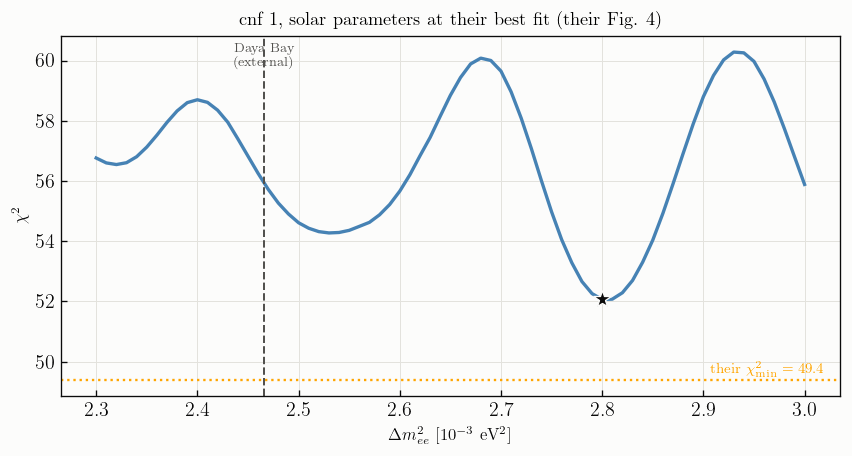

minimum: chi2 = 52.1 at dm2_ee = 2.800e-3
   their JUNO-only best fit: dm2_31 = 2.83e-3 (dm2_ee ~ 2.81e-3), chi2_min = 49.4
at the Daya Bay external value: chi2 = 55.7
swing across the scan: 8.2 units (their Fig. 4: 4-8)

Freeing dm2_ee closes most of the gap between our chi2 and theirs, at exactly their
preferred value. The remaining ~2.5 units over 63 dof are consistent with their
note-added 'more accurate data on background spectra', which we cannot access.


In [4]:
vals = np.linspace(2.30, 3.00, 71) * 1e-3
prof = []
warm = None
f1 = fits["cnf 1"]
for dmee in vals:
    mm = NuFitJUNOModel(config=CONFIGURATIONS["cnf 1"], dm2_ee=float(dmee))
    c, warm = mm._profile(f1["sin2_theta12"], f1["dm2_21"], warm)
    prof.append(c)
prof = np.array(prof)
i = prof.argmin()
i_dyb = np.argmin(np.abs(vals - 2.466e-3))

fig, ax = plt.subplots(figsize=(7.2, 3.9))
ax.plot(vals*1e3, prof, color=pl.BLUE)
ax.axvline(2.466, color=pl.INK_SECONDARY, ls="--", lw=1.2)
ax.annotate("Daya Bay\n(external)", xy=(2.466, prof.max()-0.5), ha="center", fontsize=8,
            color=pl.INK_SECONDARY)
ax.axhline(49.4, color=pl.ORANGE, ls=":", lw=1.4)
ax.annotate(r"their $\chi^2_{\rm min}=49.4$", xy=(0.98, 49.4), xycoords=("axes fraction", "data"),
            xytext=(0, 4), textcoords="offset points", ha="right", fontsize=8.5, color=pl.ORANGE)
pl.mark_best_fit(ax, vals[i]*1e3, prof[i])
ax.set_xlabel(r"$\Delta m^2_{ee}$ [$10^{-3}$ eV$^2$]"); ax.set_ylabel(r"$\chi^2$")
ax.set_title("cnf 1, solar parameters at their best fit (their Fig. 4)")
plt.tight_layout(); plt.show()

print(f"minimum: chi2 = {prof[i]:.1f} at dm2_ee = {vals[i]*1e3:.3f}e-3")
print(f"   their JUNO-only best fit: dm2_31 = 2.83e-3 (dm2_ee ~ 2.81e-3), chi2_min = 49.4")
print(f"at the Daya Bay external value: chi2 = {prof[i_dyb]:.1f}")
print(f"swing across the scan: {prof.max()-prof.min():.1f} units (their Fig. 4: 4-8)")
print()
print("Freeing dm2_ee closes most of the gap between our chi2 and theirs, at exactly their")
print("preferred value. The remaining ~2.5 units over 63 dof are consistent with their")
print("note-added 'more accurate data on background spectra', which we cannot access.")

## 4. Which ingredient does the work

Switching each fidelity item off, one at a time, from the faithful cnf 1. An earlier version
of this notebook — built **without** the bin-per-bin rescaling — concluded that the flux model
was the dominant difference between analyses, worth $0.009$ in $\sin^2\theta_{12}$. The table
below supersedes that conclusion.

In [5]:
rows = []
t0 = time.time()

def run(label, **kw):
    f = NuFitJUNOModel(config=CONFIGURATIONS["cnf 1"], **kw).fit()
    rows.append([label, f["sin2_theta12"], f["dm2_21"]*1e5, f["chi2"], pull_2d(f)])

run("faithful cnf 1")
run("  no bin-per-bin rescaling", bin_scaling=False)
run("  centre-interpolated flux, not Appendix A", flux_model="dayabay")
run("  Huber-Mueller flux (rescaling still on)", flux_model="huber-mueller",
    use_flux_pulls=False)
run("  Strumia-Vissani cross section", cross_section="strumia-vissani")
run("  no 25 flux pulls", use_flux_pulls=False)
own = JUNO2025Model().fit()
rows.append(["our JUNO2025Model (no rescaling, HM flux)", own["sin2_theta12"],
             own["dm2_21"]*1e5, own["chi2"], pull_2d(own)])
rows.append(["JUNO", JUNO2025_SIN2_THETA12, JUNO2025_DM2_21*1e5, np.nan, 0.0])
print(pl.table(rows, ["variant", "sin^2(th12)", "dm2_21 [1e-5]", "chi2", "2D pull"],
               floatfmt="{:.4f}"))
print(f"({time.time()-t0:.0f} s)")
print()
print("One ingredient carries the reproduction: the bin-per-bin rescaling to JUNO's own")
print("un-oscillated spectrum (2D pull 0.10 with it, 0.34 without). Once it is on, the flux")
print("model is nearly irrelevant -- Appendix A, centre interpolation and even plain")
print("Huber-Mueller agree to 0.0004 in sin^2(theta12) -- because the rescaling replaces the")
print("flux question with JUNO's own spectrum wherever it matters, leaving the flux to set")
print("only the within-bin oscillation weighting. The cross section is a null.")
print()
print("This supersedes the earlier reading that the flux model was the operative difference:")
print("that was true only in the absence of the rescaling, where the flux shape leaks into")
print("the dip depth. NuFit sidestep the whole question by construction, which is the")
print("cleanest available choice given that JUNO publish their un-oscillated prediction.")

variant                                     sin^2(th12)  dm2_21 [1e-5]  chi2     2D pull
----------------------------------------------------------------------------------------
faithful cnf 1                              0.3095       7.4880         55.9227  0.1026 
  no bin-per-bin rescaling                  0.3069       7.5308         59.2593  0.3375 
  centre-interpolated flux, not Appendix A  0.3098       7.4882         56.1229  0.1084 
  Huber-Mueller flux (rescaling still on)   0.3094       7.4942         56.4085  0.0513 
  Strumia-Vissani cross section             0.3096       7.4872         55.9223  0.1120 
  no 25 flux pulls                          0.3096       7.4947         56.4791  0.0591 
our JUNO2025Model (no rescaling, HM flux)   0.3138       7.4588         61.1454  0.5714 
JUNO                                        0.3092       7.5000         nan      0.0000 
(246 s)

One ingredient carries the reproduction: the bin-per-bin rescaling to JUNO's own
un-oscillated spectr

## 5. Confidence regions

(186 s)
analysis                 sigma(sin^2 th12)  sigma(dm2_21) [1e-5]  rho     
--------------------------------------------------------------------------
JUNO official map        0.00877            0.11787               -0.22416
NuFit cnf 1, reproduced  0.00819            0.11642               -0.31086
our JUNO2025Model        0.00779            0.11071               -0.32339


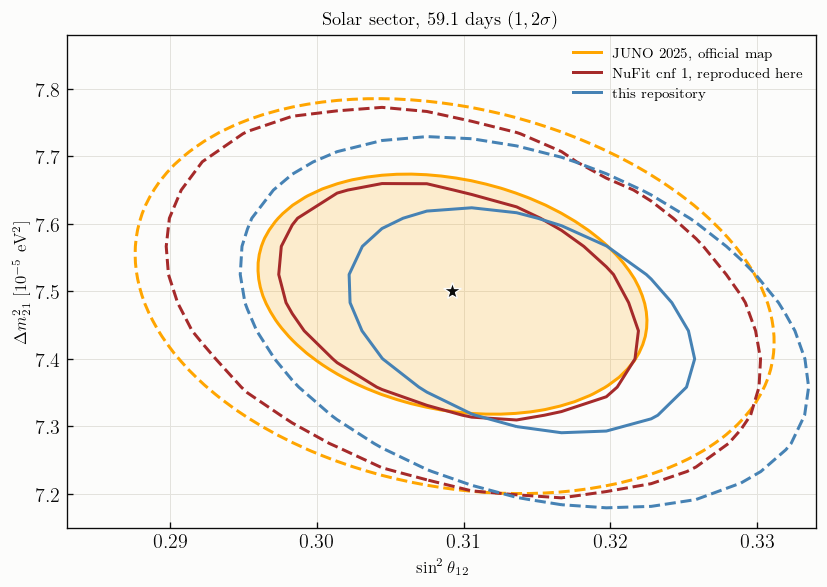

In [6]:
t0 = time.time()
s12_grid = np.linspace(0.280, 0.335, 19)
dm2_grid = np.linspace(7.15, 7.90, 19)*1e-5

g_nufit = NuFitJUNOModel(config=CONFIGURATIONS["cnf 1"]).scan(s12_grid, dm2_grid)
g_nufit -= g_nufit.min()
g_own = JUNO2025Model().scan(s12_grid, dm2_grid, profile=True)
g_own -= g_own.min()
print(f"({time.time()-t0:.0f} s)")

rows = [["JUNO official map", np.sqrt(COV_OFF[0, 0]), np.sqrt(COV_OFF[1, 1]),
         correlation_from_covariance(COV_OFF)]]
for lab, g in [("NuFit cnf 1, reproduced", g_nufit), ("our JUNO2025Model", g_own)]:
    C = covariance_from_chi2_surface(s12_grid, dm2_grid*1e5, g)
    rows.append([lab, np.sqrt(C[0, 0]), np.sqrt(C[1, 1]), correlation_from_covariance(C)])
print(pl.table(rows, ["analysis", "sigma(sin^2 th12)", "sigma(dm2_21) [1e-5]", "rho"],
               floatfmt="{:.5f}"))

fig, ax = plt.subplots(figsize=(7.0, 5.0))
pl.confidence_contours(ax, s12_off, dm2_off, chi2_off - chi2_off.min(),
                       color=pl.ORANGE, label="JUNO 2025, official map",
                       levels=pl.DELTA_CHI2_2DOF[:2])
pl.confidence_contours(ax, s12_grid, dm2_grid*1e5, g_nufit,
                       color=pl.BROWN, label="NuFit cnf 1, reproduced here",
                       levels=pl.DELTA_CHI2_2DOF[:2], fill=False)
pl.confidence_contours(ax, s12_grid, dm2_grid*1e5, g_own,
                       color=pl.BLUE, label="this repository", fill=False,
                       levels=pl.DELTA_CHI2_2DOF[:2])
pl.mark_best_fit(ax, JUNO2025_SIN2_THETA12, JUNO2025_DM2_21*1e5)
ax.set_xlabel(r"$\sin^2\theta_{12}$")
ax.set_ylabel(r"$\Delta m^2_{21}$ [$10^{-5}$ eV$^2$]")
ax.set_xlim(0.283, 0.334); ax.set_ylim(7.15, 7.88)
ax.set_title(r"Solar sector, 59.1 days ($1,2\sigma$)")
ax.legend(fontsize=8.5, loc="upper right")
plt.tight_layout(); plt.show()

## Summary

**Reproduced, with nothing tuned:**

* their Tab. 2 relative fluxes, core by core — $32.1/61.5/6.4\%$ exactly;
* their best fit: cnf 1 gives $\sin^2\theta_{12}$ within $0.03\sigma$ of JUNO's value
  ($0.10\sigma$ in 2D), and the note-added configuration lands at $-0.17\sigma$ with no
  background rescaling — the same conclusion their note added reports;
* their Fig. 4: the $\chi^2(\Delta m^2_{ee})$ profile oscillates with an $8$-unit swing and
  bottoms out at $\Delta m^2_{ee}=2.80\times10^{-3}$ eV$^2$, against their
  $2.81\times10^{-3}$; freeing $\Delta m^2_{ee}$ (their quoted $\chi^2_{\rm min}$ is a
  three-parameter minimum) accounts for most of the difference between our $\chi^2$ and
  theirs, leaving $\approx2.5$ units over 63 dof — consistent with their note-added
  background-spectrum improvements, which are not public.

**The one ingredient that matters is the bin-per-bin rescaling** of the prediction to JUNO's
own un-oscillated spectrum, which is how their cnf 1 is defined. With it, the choice of flux
model — Appendix-A cubic, centre interpolation, or plain Huber–Mueller — moves
$\sin^2\theta_{12}$ by $\lesssim0.0004$, and the cross section by less. Without it, the flux
shape leaks into the solar-dip depth and the analyses diverge at the half-sigma level. The
elaborate nuisance structure (the 25 flux pulls, the ${}^9$Li/${}^8$He shape pull, the energy
pulls, the $100\%$ `other` prior) is worth $\lesssim0.002$ altogether.

Fidelity notes for anyone comparing to the paper: $\sigma_{\rm norm}=1.8\%$ in every Tab. 1
configuration ($2.4\%$ only in the note added); $r_{\rm BG}$ excludes the geoneutrinos; their
$\chi^2_{\rm min}$ values are minimised over $\Delta m^2_{3\ell}$; and their neutron-recoil
top-hat would change the effective resolution by well under a percent relative to our
mean-energy treatment. Of the note added's three items, $\sigma_{\rm norm}=2.4\%$ is
`cnf upd`, Fangchenggang-in-signal is the `fangchenggang="signal"` option (a null,
$<0.001$ in $\sin^2\theta_{12}$ done consistently, $+0.002$ even done inconsistently), and
the improved background spectra are not public — the plausible home of the residual
$\approx2.5$ $\chi^2$ units.